# SAM3 : Détection de passages piétons

Use case : segmentation zero-shot de passages piétons (zebra crossing) sur orthophoto IGN 2024 (20 cm/pixel, tuiles 512×512).

## 1. Config

In [1]:
MODEL_ID = "facebook/sam3"
PROMPT = "pedestrian crossing"
THRESHOLD = 0.50
OPACITY = 0.45
COLOR = (255, 50, 50)

INPUT_PATH = "demo_img/tile_00131.tif"
OUTPUT_DIR = "output/"

## 2. Validation et lecture

CRS       : EPSG:2154
Taille    : 512×512 px
Transform : | 0.20, 0.00, 647679.00|
| 0.00,-0.20, 6858169.00|
| 0.00, 0.00, 1.00|


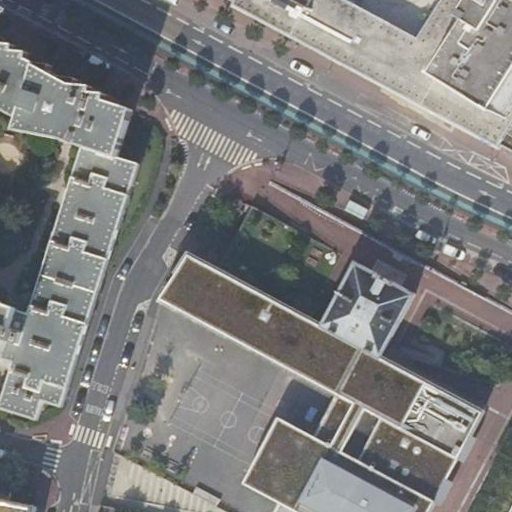

In [2]:
from geo_sam3_inference import GeoImageReader, validate_geotiff

validate_geotiff(INPUT_PATH)
image, geo_meta = GeoImageReader.read(INPUT_PATH)

print(f"CRS       : {geo_meta.crs}")
print(f"Taille    : {geo_meta.width}×{geo_meta.height} px")
print(f"Transform : {geo_meta.transform}")
image

## 3. Inférence SAM3

In [3]:
from geo_sam3_inference import Sam3InferenceEngine

engine = Sam3InferenceEngine(MODEL_ID)
masks = engine.predict_masks(image, PROMPT, THRESHOLD)

print(f"{len(masks)} masque(s) détecté(s)")

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

3 masque(s) détecté(s)


## 4. Visualisation

Passages détectés : 3
Couverture        : 1.22%
  Passage #1 : 482 px
  Passage #2 : 717 px
  Passage #3 : 2,012 px


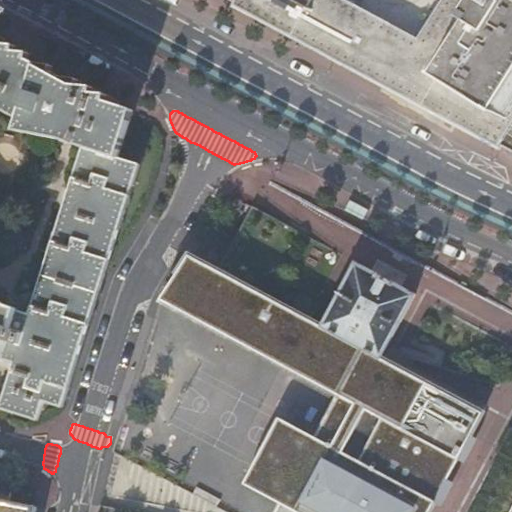

In [4]:
from geo_sam3_inference import compute_stats, draw_contours, draw_overlay

viz = draw_overlay(image, masks, COLOR, OPACITY)
viz = draw_contours(viz, masks, COLOR)

stats = compute_stats(masks, image)
print(f"Passages détectés : {stats['count']}")
print(f"Couverture        : {stats['coverage_pct']}%")
for i, area in enumerate(stats["areas"]):
    print(f"  Passage #{i + 1} : {area:,} px")

viz

## 5. Export géospatial

In [5]:
from pathlib import Path
from geo_sam3_inference import export_geojson, export_geotiff

out = Path(OUTPUT_DIR)
export_geotiff(masks, geo_meta, out / "pedestrian_crossings.tif")
export_geojson(masks, geo_meta, out / "pedestrian_crossings.geojson")
viz.save(out / "visualization.png")

print("Fichiers exportés :")
for f in sorted(out.iterdir()):
    print(f"  {f.name}")

Fichiers exportés :
  pedestrian_crossings.geojson
  pedestrian_crossings.tif
  visualization.png


-- END --